# 02 · NDVI in windows with a whole-array check

Process an actual Sentinel-2 L2A crop while keeping array sizes independent of total scene size. Compare the output grid, mask, and values against a small reference.

[Notebook index](README.md) · [Companion article](../docs/articles/memory-bounded-rasters.md) · [Data sources and licences](../docs/DATA_SOURCES.md)

Run every cell from top to bottom in the locked Python 3.12 environment. The first run downloads the required public data pack and checks its SHA-256. Generated artifacts remain in the ignored `outputs/` directory.

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython import get_ipython
from IPython.display import display

from geoai_portfolio.io import ensure_data, workspace

get_ipython().run_line_magic("matplotlib", "inline")
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "figure.figsize": (10, 4),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "axes.labelsize": 9,
        "axes.titlesize": 11,
        "font.size": 10,
        "savefig.bbox": "tight",
    }
)
pd.set_option("display.precision", 4)

In [2]:
import time

import rasterio

from geoai_portfolio.rasters import grid, map_array, scene_ndvi, windowed_ndvi

data = ensure_data("satellite")
out = workspace("02-rasters")
provenance = json.loads((data / "provenance.json").read_text())
display(
    pd.DataFrame(
        [
            {k: row[k] for k in ["id", "datetime", "processing_baseline"]}
            for row in provenance["sentinel"]
        ]
    )
)
with rasterio.open(data / "before.tif") as source:
    display(
        pd.DataFrame(
            {"band": source.descriptions, "scale": source.scales, "offset": source.offsets}
        )
    )
    print(grid(source))

,id,datetime,processing_baseline
0,S2A_T10TFK_20200812T185701_L2A,2020-08-12T19:03:28.562000Z,05.00
1,S2A_T10TFK_20210827T185458_L2A,2021-08-27T19:03:24.370000Z,05.00


,band,scale,offset
0,red,0.0001,-0.1
1,green,0.0001,-0.1
2,blue,0.0001,-0.1
3,nir,0.0001,-0.1


{'crs': 'EPSG:32610', 'shape': (512, 512), 'transform': (10.0, 0.0, 660670.0, 0.0, -10.0, 4443180.0)}


## Make valid pixels explicit

The crop is 512 × 512 at 10 m in UTM zone 10N (EPSG:32610), north of Lake Almanor,
California. Red and NIR are surface-reflectance bands from 12 August 2020, C1 L2A,
processing baseline 05.00. Raw zero is nodata. Each band is calibrated once using its
saved scale and offset. SCL classes 4, 5, 6, 7 are retained; cloud, cirrus, shadow,
snow, defective and missing pixels are excluded. Class 7 is uncertain and needs visual
inspection. Negative reflectance and near-zero denominators are also masked.

In [3]:
reference = scene_ndvi(data / "before.tif", data / "before-scl.tif")
results = []
for size in [64, 128, 256]:
    started = time.perf_counter()
    path = out / f"ndvi-{size}.tif"
    summary = windowed_ndvi(data / "before.tif", data / "before-scl.tif", path, size)
    with rasterio.open(path) as saved, rasterio.open(data / "before.tif") as source:
        actual = saved.read(1, masked=True)
        assert grid(saved) == grid(source)
        np.testing.assert_array_equal(actual.mask, reference.mask)
        np.testing.assert_allclose(actual.compressed(), reference.compressed(), atol=1e-6, rtol=0)
        assert saved.tags(ns="IMAGE_STRUCTURE").get("LAYOUT") == "COG"
    results.append(
        {
            **summary,
            "seconds": time.perf_counter() - started,
            "max_abs_difference": float(np.max(np.abs(actual - reference))),
        }
    )
display(pd.DataFrame(results))

,windows,valid_pixels,window_size,largest_input_pixels,seconds,max_abs_difference
0,64,261429,64,4096,0.3298,0.0
1,16,261429,128,16384,0.1839,0.0
2,4,261429,256,65536,0.2167,0.0


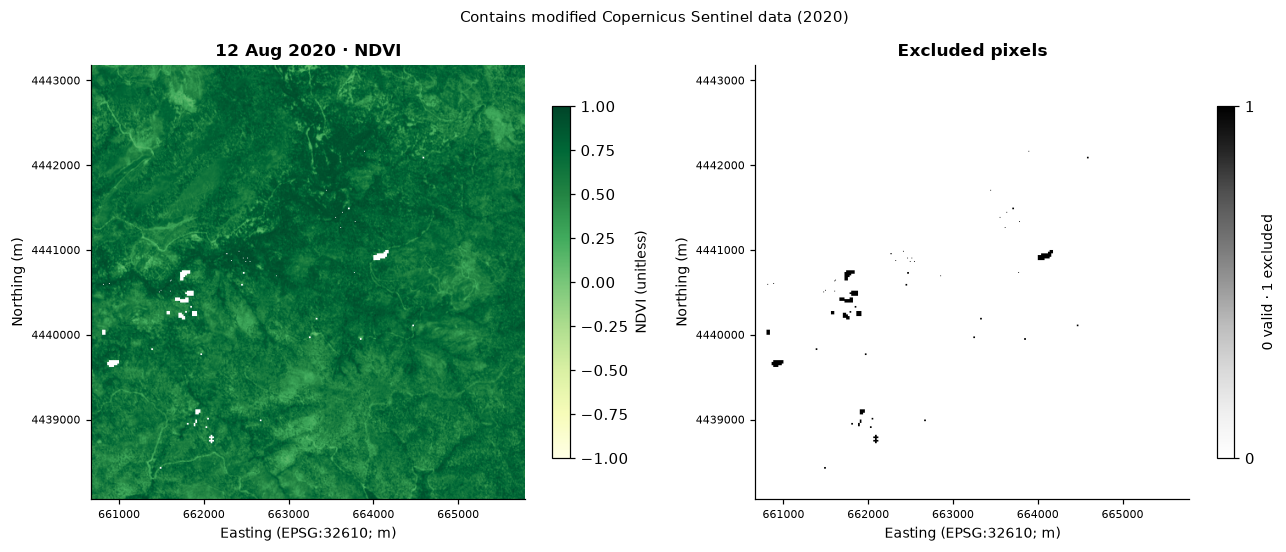

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
with rasterio.open(data / "before.tif") as source:
    image = map_array(axes[0], reference, source, "12 Aug 2020 · NDVI", "YlGn", -1, 1)
    fig.colorbar(image, ax=axes[0], label="NDVI (unitless)", shrink=0.75)
    mask = np.ma.getmaskarray(reference).astype("uint8")
    image = map_array(axes[1], mask, source, "Excluded pixels", "Greys", 0, 1)
    fig.colorbar(image, ax=axes[1], ticks=[0, 1], label="0 valid · 1 excluded", shrink=0.75)
fig.suptitle("Contains modified Copernicus Sentinel data (2020)", fontsize=10)
plt.tight_layout()
plt.show()

## What this proves

All window sizes must produce the same numerical result and mask. Processing uses tiled
scratch storage and then translates it to a COG; it never allocates a scene-sized result
inside the windowed function. The whole-array reference is deliberately small and exists
only for verification. `largest_input_pixels` is an array-size bound, not a measurement
of process RSS: GDAL blocks, caches, compression and Python add memory costs. A COG layout
tag and successful reopen are useful checks, not independent full conformance certification.

[Rasterio windowed I/O](https://rasterio.readthedocs.io/en/stable/topics/windowed-rw.html)
explains why actual network and disk reads also depend on the source block layout.